## Land cover classification gridded maps from 1992 to present derived from satellite observations

https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=overview

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

In [2]:
dataset = "satellite-land-cover"
request = {
    "variable": "all",
    "area": [50, 5, 40, 15],
    "year": "2021",
    "version": [
        "v2_1_1"
    ]
}

In [3]:
data = ekd.from_source("cds", dataset, request)

2026-03-23 10:08:26,866 INFO [2025-07-04T00:00:00] Due to a transition between project phases, there are changes to the timeline of this dataset updates, which are usually on an annual basis with a one year delay: 2023 and 2024 data updates are now expected during 2026. Please watch the [forum](https://forum.ecmwf.int/c/announcements/5) for future announcements.
2026-03-23 10:08:26,868 INFO Request ID is fba1ab00-2bdf-4183-8720-9430846e7848
2026-03-23 10:08:26,958 INFO status has been updated to accepted
2026-03-23 10:08:40,829 INFO status has been updated to running
2026-03-23 10:09:17,366 INFO status has been updated to accepted
2026-03-23 10:09:43,139 INFO status has been updated to running
2026-03-23 10:14:47,535 INFO status has been updated to successful


In [4]:
ds = data.to_xarray()

In [5]:
lccs_class = ds.lccs_class.squeeze()
lccs_class

<xarray.DataArray 'lccs_class' (lat: 3600, lon: 3600)> Size: 13MB
dask.array<getitem, shape=(3600, 3600), dtype=uint8, chunksize=(3600, 3600), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 29kB 50.0 50.0 49.99 49.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float64 29kB 5.001 5.004 5.007 5.01 ... 14.99 14.99 15.0 15.0
    time     datetime64[ns] 8B 2021-01-01
Attributes:
    standard_name:        land_cover_lccs
    flag_colors:          #ffff64 #ffff64 #ffff00 #aaf0f0 #dcf064 #c8c864 #00...
    long_name:            Land cover class defined in LCCS
    valid_min:            1
    valid_max:            220
    ancillary_variables:  processed_flag current_pixel_state observation_coun...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    flag_values:          [  0  10  11  12  20  30  40  50  60  61  62  70  7...

In [6]:
levels, colors = zip(*[
    [0, "#000000"],
    [10, "#ffff64"],
    [20, "#aaf0f0"],
    [30, "#dcf064"],
    [40, "#c8c864"],
    [50, "#006400"],
    [60, "#00a000"],
    [70, "#003c00"],
    [80, "#285000"],
    [90, "#788200"],
    [100, "#8ca000"],
    [110, "#be9600"],
    [120, "#966400"],
    [130, "#ffb432"],
    [140, "#ffdcd2"],
    [150, "#ffebaf"],
    [160, "#00785a"],
    [170, "#009678"],
    [180, "#00dc82"],
    [190, "#c31400"],
    [200, "#fff5d7"],
    [210, "#0046c8"],
    [220, "#ffffff"],
])

style = ekp.styles.Categorical(
    levels=levels,
    colors=colors,
    legend_style=None,
)

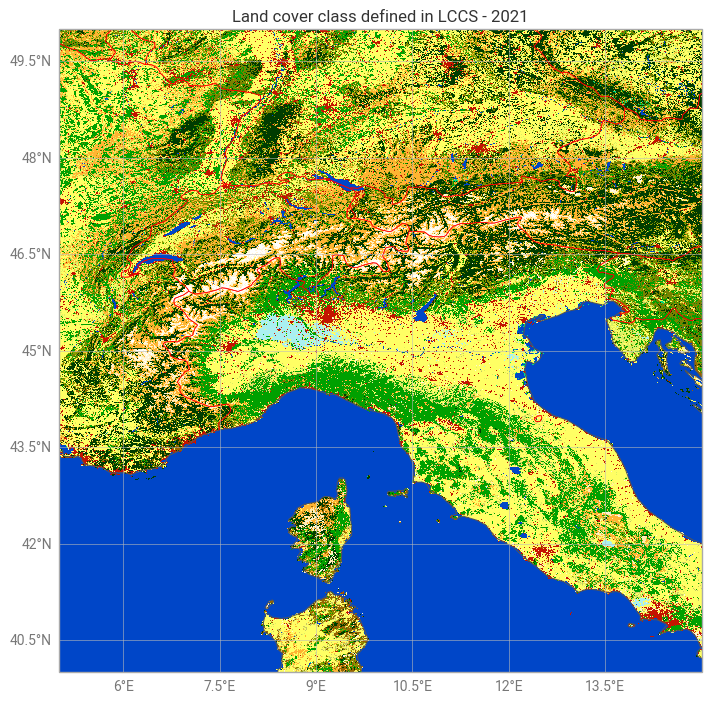

In [12]:
chart = ekp.Map()

chart.grid_cells(lccs_class, style=style)

chart.coastlines()
chart.borders(color="red")
chart.gridlines()

chart.title("{variable_name} - {time:%Y}")

chart.show()